In [1]:
import re
import gzip
import zipfile
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess as sp
import seaborn as sns

import tqdm
import time
import os
import io
import json
import shutil
import random
import yaml
import collections


# # to setup the environment for AMR_atlas_search.ipynb
# mamba create -n venv 

# mamba install pip

# pip install jupyter
# pip install pandas
# pip install seaborn
# pip install requests
# pip install biopython

# pip install jedi==0.17.2
# pip install mongodict
# pip install -U memory_profiler
# pip install pymongo
# pip install "holoviews[recommended]"
# pip install datashader
# pip install holoviews
# pip install umap-learn
# pip install faerun

# # to initiate the environment for AMR_atlas_search.ipynb
# mamba activate venv

In [2]:
# For sequence searches over the proteins in the atlas, MMseqs2 easy-search is used.
# As input, provide protein FASTA files for your target pathogen merged or placed in a directory.
# As the search "database", use the AFDBv4_90.fasta file.
# For each protein in the input file, the best match is taken.
#
# Run in terminal (replace PATHOGEN with your organism label, e.g. SA, PA, KP):
#   mmseqs easy-search PATHOGEN_faa.tar.gz AFDBv4_90.fasta PATHOGEN.m8 tmp --max-seqs 1
#
# Then set M8_FILE below to point to the resulting .m8 file.

In [3]:
# -- UNIVERSAL CONFIG -- change only this line for each new pathogen --------
M8_FILE = './PA.m8'   # path to your MMseqs2 .m8 search result file
#   e.g. './SA.m8' for S. aureus, './KP.m8' for K. pneumoniae, etc.
# -------------------------------------------------------------------------

# load mmseqs2 alignment results
atlas_search_results_info = [M8_FILE]

atlas_search_results = None

for f in atlas_search_results_info:
    print(f)
    atlas_search_results = pd.read_csv(
        f, sep='\t',
        names=['queryID', 'targetID', 'fident', 'alnlen', 'mismatch',
               'gapopen', 'qstart', 'qend', 'tstart', 'tend', 'eVal', 'bits']
    )

atlas_search_results  # here 'targetIDs' are UniRef50 representatives from the atlas

./PA.m8


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits
0,QLX61_RS27085,W9SYN9,0.940,355,21,0,4,358,3,356,2.248000e-223,697
1,M0418_RS10560,A0A109LHD2,0.821,397,71,0,1,397,1,397,1.899000e-215,670
2,M0418_RS10720,A0A2W0B2F2,0.358,224,143,0,15,237,13,236,5.420000e-27,121
3,M0418_RS23985,A0A259UNW9,0.322,421,285,0,9,429,9,429,7.784000e-68,245
4,M0418_RS24145,A0A1J4XIL7,0.421,147,84,0,1,147,1,146,5.899000e-25,107
...,...,...,...,...,...,...,...,...,...,...,...,...
3460652,M2I89_RS25900,A0A5C7LXQ1,0.442,165,92,0,1,165,19,183,9.854000e-27,113
3460653,M2I89_RS31675,A0A7Y1FVV3,0.593,160,65,0,1,160,1,160,1.580000e-45,167
3460654,M2I89_RS31835,A0A0H3YTV6,0.800,95,19,0,1,95,1,95,9.545000e-46,164
3460655,PALA22_RS09530,A0A2V6IGP8,0.413,104,60,0,49,152,1,104,1.069000e-19,92


In [4]:
#drop duplicates queryIDs in atlas_search_results

atlas_search_results = atlas_search_results.drop_duplicates(subset='queryID')
atlas_search_results

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits
0,QLX61_RS27085,W9SYN9,0.940,355,21,0,4,358,3,356,2.248000e-223,697
1,M0418_RS10560,A0A109LHD2,0.821,397,71,0,1,397,1,397,1.899000e-215,670
2,M0418_RS10720,A0A2W0B2F2,0.358,224,143,0,15,237,13,236,5.420000e-27,121
3,M0418_RS23985,A0A259UNW9,0.322,421,285,0,9,429,9,429,7.784000e-68,245
4,M0418_RS24145,A0A1J4XIL7,0.421,147,84,0,1,147,1,146,5.899000e-25,107
...,...,...,...,...,...,...,...,...,...,...,...,...
3460652,M2I89_RS25900,A0A5C7LXQ1,0.442,165,92,0,1,165,19,183,9.854000e-27,113
3460653,M2I89_RS31675,A0A7Y1FVV3,0.593,160,65,0,1,160,1,160,1.580000e-45,167
3460654,M2I89_RS31835,A0A0H3YTV6,0.800,95,19,0,1,95,1,95,9.545000e-46,164
3460655,PALA22_RS09530,A0A2V6IGP8,0.413,104,60,0,49,152,1,104,1.069000e-19,92


In [5]:
# load all the atlas data 
# it excludes anything uniparc

atlas_datafiles = ['AFDB90v4_cc_data_uniprot_community_taxonomy_map_with_brightness.csv',
                   'AFDB90v4_dust_uniprot_community_taxonomy_map_with_brightness.csv']

atlas_data = None
for f in atlas_datafiles:
    print(f)
    label = f.split('AFDB90v4_')[-1].split('_')[0]
    
    df = pd.read_csv(f, sep=',')
    df['label'] = label
    
    if atlas_data is None:
        atlas_data = df.copy()
    else:
        atlas_data = pd.concat([atlas_data, df], axis=0)
        
atlas_data

AFDB90v4_cc_data_uniprot_community_taxonomy_map_with_brightness.csv
AFDB90v4_dust_uniprot_community_taxonomy_map_with_brightness.csv


,uniprotIDs,superkingdom,phylum,class,order,genus,species,UniRef50IDs,communityIDs,brightness,label
0,E2MW64,Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Corynebacterium,Corynebacterium amycolatum,UniRef50_E2MW64,1920284[0],96.68,cc
1,D4XKM5,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter haemolyticus,UniRef50_N9TGA3,21487[0],99.09,cc
2,N9TGA3,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter genomosp. 16BJ,UniRef50_N9TGA3,21487[0],99.09,cc
3,A0A072CTB8,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. ETR1,UniRef50_N8WWZ2,51933[0],86.73,cc
4,A0A077KXT1,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter guillouiae,UniRef50_N8WWZ2,51933[0],86.73,cc
...,...,...,...,...,...,...,...,...,...,...,...
4727593,A0A7S2D1G0,Eukaryota,Haptophyta,NaN,Prymnesiales,Haptolina,Haptolina brevifila,UniRef50_A0A7S2D1G0,1612739[0],66.96,dust
4727594,A0A7S7T862,Bacteria,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Bradyrhizobium,Bradyrhizobium sp. CCBAU 51765,UniRef50_A0A7S7T862,1627339[0],86.50,dust
4727595,A0A7M5UYP5,Eukaryota,Cnidaria,Hydrozoa,Leptothecata,Clytia,Clytia hemisphaerica,UniRef50_A0A7M5WQ56,1597478[0],98.96,dust
4727596,A0A7M5WQ56,Eukaryota,Cnidaria,Hydrozoa,Leptothecata,Clytia,Clytia hemisphaerica,UniRef50_A0A7M5WQ56,1597478[0],98.96,dust


In [6]:
# drop 'UniRef50_' in UniRef50ID names and add componentIDs 

atlas_data['UniRef50IDs'] = atlas_data['UniRef50IDs'].apply(lambda x: x.split('_')[1])
atlas_data['componentIDs'] = atlas_data['communityIDs'].apply(lambda x: x.split('[')[0]).astype('int64')

atlas_data

,uniprotIDs,superkingdom,phylum,class,order,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
0,E2MW64,Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Corynebacterium,Corynebacterium amycolatum,E2MW64,1920284[0],96.68,cc,1920284
1,D4XKM5,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter haemolyticus,N9TGA3,21487[0],99.09,cc,21487
2,N9TGA3,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter genomosp. 16BJ,N9TGA3,21487[0],99.09,cc,21487
3,A0A072CTB8,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. ETR1,N8WWZ2,51933[0],86.73,cc,51933
4,A0A077KXT1,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter guillouiae,N8WWZ2,51933[0],86.73,cc,51933
...,...,...,...,...,...,...,...,...,...,...,...,...
4727593,A0A7S2D1G0,Eukaryota,Haptophyta,NaN,Prymnesiales,Haptolina,Haptolina brevifila,A0A7S2D1G0,1612739[0],66.96,dust,1612739
4727594,A0A7S7T862,Bacteria,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Bradyrhizobium,Bradyrhizobium sp. CCBAU 51765,A0A7S7T862,1627339[0],86.50,dust,1627339
4727595,A0A7M5UYP5,Eukaryota,Cnidaria,Hydrozoa,Leptothecata,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.96,dust,1597478
4727596,A0A7M5WQ56,Eukaryota,Cnidaria,Hydrozoa,Leptothecata,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.96,dust,1597478


In [7]:
#sort values in the atlas_search_results by targetID

atlas_search_results.sort_values(by='targetID', inplace=True)
atlas_search_results

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_89879/752831130.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results.sort_values(by='targetID', inplace=True)


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits
599410,A6R75_RS04155,A0A009EQY8,0.550,40,18,0,5,44,14,53,2.142000e-06,51
1243866,BFV99_RS29425,A0A009EQY8,0.380,42,25,0,2,43,12,53,4.523000e-04,46
3109409,Y82_RS05740,A0A009EQY8,0.380,42,25,0,2,43,12,53,2.134000e-05,46
305126,IOMTU133_RS01595,A0A009EQY8,0.550,40,18,0,5,44,14,53,2.142000e-06,51
524532,PMJ92_RS11905,A0A009EQY8,0.511,45,22,0,19,63,9,53,1.081000e-06,53
...,...,...,...,...,...,...,...,...,...,...,...,...
1955936,M8G39_RS12530,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222
2062461,PALA44_RS18320,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222
621706,EL342_RS21235,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222
322347,FOY97_RS12080,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222


In [8]:
# Select only those UniRef50 representatives in the atlas data that are in atlas_search_results and drop duplicates

atlas_data_selected = atlas_data.loc[atlas_data['UniRef50IDs'].isin(atlas_search_results['targetID'])]
atlas_data_selected = atlas_data_selected.drop_duplicates(subset='UniRef50IDs')
atlas_data_selected.sort_values(by='UniRef50IDs', inplace=True)
atlas_data_selected

,uniprotIDs,superkingdom,phylum,class,order,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
19772366,A0A009EQY8,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter baumannii,A0A009EQY8,0[64256],94.58,cc,0
1597139,A0A009ZFP6,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. 479375,A0A009ZFP6,242909[0],0.00,dust,242909
19928362,A0A010RHE6,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonas,Pseudomonas fluorescens,A0A010RHE6,0[7537],82.81,cc,0
1617157,A0A010RPD7,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonas,Pseudomonas fluorescens,A0A010RPD7,242944[0],0.00,dust,242944
1616414,A0A010RVP0,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonas,Pseudomonas fluorescens,A0A010RVP0,242950[0],39.81,dust,242950
...,...,...,...,...,...,...,...,...,...,...,...,...
2646341,X7E826,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Roseivivax,Roseivivax halodurans,X7E826,2108109[0],0.00,dust,2108109
2667291,X7F381,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Roseivivax,Roseivivax isoporae,X7F381,2108185[0],0.00,dust,2108185
2647342,A0A8J3B3D2,Bacteria,Actinomycetota,Actinomycetes,Micromonosporales,Pilimelia,Pilimelia anulata,X8AAB5,2108296[0],0.00,dust,2108296
2653555,A0A3S4NIC2,Bacteria,Bacillota,Bacilli,Lactobacillales,Streptococcus,Streptococcus milleri,X8H8H1,2108502[0],0.00,dust,2108502


In [9]:
# map communityID to each targetID in the atlas_search_results

communityID = []
previous_targetID = ''

for targetID in tqdm.tqdm(atlas_search_results['targetID'], total=len(atlas_search_results), desc=' ... Collecting targetID counts', bar_format="{l_bar}{bar}{r_bar} [ time left: {remaining}, time spent: {elapsed}]", position=0, leave=True):
    
    if targetID != previous_targetID:
        
        cur_communityID = atlas_data_selected['communityIDs'].loc[atlas_data_selected['UniRef50IDs'] == targetID].values[0]
        previous_targetID = targetID
    
    communityID.append(cur_communityID)


atlas_search_results_maped = atlas_search_results.copy()

atlas_search_results_maped['communityID'] = communityID
atlas_search_results_maped

 ... Collecting targetID counts: 100%|██████████| 3457506/3457506 [00:17<00:00, 198958.23it/s] [ time left: 00:00, time spent: 00:17]


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID
599410,A6R75_RS04155,A0A009EQY8,0.550,40,18,0,5,44,14,53,2.142000e-06,51,0[64256]
1243866,BFV99_RS29425,A0A009EQY8,0.380,42,25,0,2,43,12,53,4.523000e-04,46,0[64256]
3109409,Y82_RS05740,A0A009EQY8,0.380,42,25,0,2,43,12,53,2.134000e-05,46,0[64256]
305126,IOMTU133_RS01595,A0A009EQY8,0.550,40,18,0,5,44,14,53,2.142000e-06,51,0[64256]
524532,PMJ92_RS11905,A0A009EQY8,0.511,45,22,0,19,63,9,53,1.081000e-06,53,0[64256]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1955936,M8G39_RS12530,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222,0[187267]
2062461,PALA44_RS18320,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222,0[187267]
621706,EL342_RS21235,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222,0[187267]
322347,FOY97_RS12080,X8HT04,0.306,583,334,0,28,610,9,490,3.119000e-58,222,0[187267]


In [10]:
# map brightness value to each communityID in the atlas_search_results
# here and below brightness and darkness are used for the same values

atlas_search_results_maped.sort_values(by='communityID', inplace=True)
atlas_data_selected.sort_values(by='communityIDs', inplace=True)

brightness = []

previous_communityID = ''

for communityID in tqdm.tqdm(atlas_search_results_maped['communityID'], total=len(atlas_search_results_maped), desc=' ... Collecting communityID counts', bar_format="{l_bar}{bar}{r_bar} [ time left: {remaining}, time spent: {elapsed}]", position=0, leave=True):
    
    if communityID != previous_communityID:
        
        cur_brightness = atlas_data_selected['brightness'].loc[atlas_data_selected['communityIDs'] == communityID].values[0]
        previous_communityID = communityID
    
    brightness.append(cur_brightness)

atlas_search_results_maped['brightness'] = brightness
atlas_search_results_maped

 ... Collecting communityID counts: 100%|██████████| 3457506/3457506 [00:13<00:00, 254335.57it/s] [ time left: 00:00, time spent: 00:13]


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32
507016,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32
2405150,LXN03_RS16670,A0A072ZHN0,0.994,193,1,0,1,193,1,193,6.246000e-124,394,0[100010],98.44
2200131,OSZ59_RS12480,A0A072ZHN0,0.994,193,1,0,1,193,1,193,1.174000e-123,394,0[100010],98.44
885217,LSP20_RS17400,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904413,P7I96_RS13175,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.00
1334974,JHW37_RS11750,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.00
3263906,CWI23_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.00
691901,CWI22_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.00


In [11]:
# map the componentID to each targetIDs in the atlas_search_results_maped
# as in the communityID name the number before the square brackets is the componentID, we can simply take that number as the componentID 

atlas_search_results_maped['componentID'] = atlas_search_results_maped['communityID'].apply(lambda x: x.split('[')[0]).astype(int)
atlas_search_results_maped

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0
507016,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0
2405150,LXN03_RS16670,A0A072ZHN0,0.994,193,1,0,1,193,1,193,6.246000e-124,394,0[100010],98.44,0
2200131,OSZ59_RS12480,A0A072ZHN0,0.994,193,1,0,1,193,1,193,1.174000e-123,394,0[100010],98.44,0
885217,LSP20_RS17400,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904413,P7I96_RS13175,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.00,9
1334974,JHW37_RS11750,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.00,9
3263906,CWI23_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.00,9
691901,CWI22_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.00,9


In [12]:
# load the components data 

components_datafiles = ['AFDB90v4_subgraphs_summary.csv']

components_data = None
for f in components_datafiles:
    print(f)
    
    components_data = pd.read_csv(f, sep=',')
        
components_data # here 'Subgraph' is componentID

AFDB90v4_subgraphs_summary.csv


,Subgraph,Avg_darkness,SD_darkness,N_members,TM,SP,Median_length,MAD_length,Median_darkness,MAD_darkness,N_communities
0,0,88.965221,22.034931,3036238,0.272574,0.272574,233.0,98.0,97.440,2.050,358579
1,1,88.189645,28.734713,1946,0.000000,0.000000,278.0,29.0,98.230,0.830,298
2,2,91.191058,11.996458,1871,2.030999,2.030999,493.0,49.0,95.000,2.020,301
3,3,83.702536,26.760281,1672,0.000000,0.000000,180.5,41.5,94.035,3.835,143
4,4,80.757456,26.934344,1490,0.000000,0.000000,139.0,7.0,94.160,3.705,213
...,...,...,...,...,...,...,...,...,...,...,...
242871,147996,98.270000,1.390000,2,0.000000,0.000000,223.5,94.5,98.270,1.390,1
242872,147995,0.000000,0.000000,2,0.000000,0.000000,184.0,0.0,0.000,0.000,1
242873,147994,0.000000,0.000000,2,0.000000,0.000000,326.0,76.0,0.000,0.000,1
242874,147993,0.000000,0.000000,2,0.000000,0.000000,226.0,90.0,0.000,0.000,1


In [13]:
# atlas_search_results_maped has UniRef50 representatives that belong to components that are upsent in components_data
# separate such UniRef50 representatives to a separate data frame

atlas_search_results_maped_without_componentID = atlas_search_results_maped.loc[~(atlas_search_results_maped['componentID'].isin(components_data['Subgraph']))]
atlas_search_results_maped_without_componentID

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID
2384440,BBX44_RS05790,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021
3455736,HW11_RS22910,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021
1597153,HW01_RS15140,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021
2002594,PMJ90_RS13005,A0A377BZV4,0.584,264,109,0,1,264,1,264,1.905000e-94,330,1000022[0],0.0,1000022
365371,PMJ94_RS14110,A0A377BZV4,0.584,264,109,0,1,264,1,264,1.905000e-94,330,1000022[0],0.0,1000022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166832,IPV46_RS15215,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972
560333,CS058_RS14935,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972
731828,JBL36_RS25885,A0A376TJA6,0.573,115,48,0,209,322,2,116,9.658000e-26,116,999972[0],0.0,999972
972267,HUK75_RS15370,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972


In [14]:
# separate those UniRef50 representatives that form components 

atlas_search_results_maped_with_componentID = atlas_search_results_maped.loc[atlas_search_results_maped['componentID'].isin(components_data['Subgraph'])]
atlas_search_results_maped_with_componentID

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0
507016,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0
2405150,LXN03_RS16670,A0A072ZHN0,0.994,193,1,0,1,193,1,193,6.246000e-124,394,0[100010],98.44,0
2200131,OSZ59_RS12480,A0A072ZHN0,0.994,193,1,0,1,193,1,193,1.174000e-123,394,0[100010],98.44,0
885217,LSP20_RS17400,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904413,P7I96_RS13175,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.00,9
1334974,JHW37_RS11750,A0A8G3UQ23,1.000,75,0,0,1,75,1,75,1.991000e-43,156,9[98],0.00,9
3263906,CWI23_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.00,9
691901,CWI22_RS12050,A0A1K1VTB8,0.662,320,108,0,1,320,1,320,4.438000e-132,425,9[98],0.00,9


In [15]:
#select target components from the component data 

components_data_selected = components_data.loc[components_data['Subgraph'].isin(atlas_search_results_maped_with_componentID['componentID'])]
components_data_selected

,Subgraph,Avg_darkness,SD_darkness,N_members,TM,SP,Median_length,MAD_length,Median_darkness,MAD_darkness,N_communities
0,0,88.965221,22.034931,3036238,0.272574,0.272574,233.0,98.0,97.440,2.050,358579
2,2,91.191058,11.996458,1871,2.030999,2.030999,493.0,49.0,95.000,2.020,301
3,3,83.702536,26.760281,1672,0.000000,0.000000,180.5,41.5,94.035,3.835,143
4,4,80.757456,26.934344,1490,0.000000,0.000000,139.0,7.0,94.160,3.705,213
5,5,96.206085,9.302048,1346,0.000000,0.000000,184.0,9.0,97.850,1.040,247
...,...,...,...,...,...,...,...,...,...,...,...
242291,147465,4.840000,4.840000,2,0.000000,0.000000,235.5,90.5,4.840,4.840,1
242384,148205,60.805000,2.495000,2,0.000000,0.000000,358.0,3.0,60.805,2.495,1
242540,148300,0.000000,0.000000,2,0.000000,0.000000,317.0,131.0,0.000,0.000,1
242859,148007,77.845000,13.695000,2,0.000000,0.000000,259.5,58.5,77.845,13.695,1


In [16]:
#add componentID median brightness to each component in the atlas_search_results_maped_with_componentID

atlas_search_results_maped_with_componentID.sort_values(by='componentID', inplace=True)

component_brightness = []
previous_componentID = ''

for componentID in tqdm.tqdm(atlas_search_results_maped_with_componentID['componentID'], total=len(atlas_search_results_maped_with_componentID), desc=' ... Collecting componentID counts', bar_format="{l_bar}{bar}{r_bar} [ time left: {remaining}, time spent: {elapsed}]", position=0, leave=True):
        
    if componentID != previous_componentID:
        
        cur_brightness = components_data_selected['Median_darkness'].loc[components_data_selected['Subgraph'] == componentID].values[0]
        previous_componentID = componentID
    
    component_brightness.append(cur_brightness)


atlas_search_results_maped_with_componentID['component_brightness'] = component_brightness
atlas_search_results_maped_with_componentID

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_89879/1208085431.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_with_componentID.sort_values(by='componentID', inplace=True)
 ... Collecting componentID counts: 100%|██████████| 2870087/2870087 [00:00<00:00, 3585359.73it/s] [ time left: 00:00, time spent: 00:00]
/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_89879/1208085431.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_with_componentID['component_brightness'] = component_bright

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44
1638450,M8341_RS07390,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
221718,CSC26_RS30115,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
2045780,M0418_RS17410,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
344606,MMG97_RS21935,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1916968,KUU79_RS31925,T1D0U5,0.327,162,106,0,218,379,2,159,7.539000e-09,65,242095[0],97.53,242095,82.52
77244,EGY27_RS02945,T1D0U5,0.327,162,106,0,218,379,2,159,7.539000e-09,65,242095[0],97.53,242095,82.52
2612260,IE752_RS27135,T1D0U5,0.327,162,106,0,194,355,2,159,6.704000e-09,65,242095[0],97.53,242095,82.52
2768925,CWI21_RS28970,T1D0U5,0.327,162,106,0,194,355,2,159,6.704000e-09,65,242095[0],97.53,242095,82.52


In [17]:
# add component_brightness column in the atlas_search_results_maped_without_componentID df

atlas_search_results_maped_without_componentID['component_brightness'] = np.nan
atlas_search_results_maped_without_componentID

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_89879/1510285853.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_without_componentID['component_brightness'] = np.nan


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness
2384440,BBX44_RS05790,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021,NaN
3455736,HW11_RS22910,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021,NaN
1597153,HW01_RS15140,A0A377BYF3,0.344,93,59,0,91,183,1,91,5.327000e-08,59,1000021[0],0.0,1000021,NaN
2002594,PMJ90_RS13005,A0A377BZV4,0.584,264,109,0,1,264,1,264,1.905000e-94,330,1000022[0],0.0,1000022,NaN
365371,PMJ94_RS14110,A0A377BZV4,0.584,264,109,0,1,264,1,264,1.905000e-94,330,1000022[0],0.0,1000022,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166832,IPV46_RS15215,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972,NaN
560333,CS058_RS14935,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972,NaN
731828,JBL36_RS25885,A0A376TJA6,0.573,115,48,0,209,322,2,116,9.658000e-26,116,999972[0],0.0,999972,NaN
972267,HUK75_RS15370,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.0,999972,NaN


In [18]:
# combine atlas_search_results_maped_with_componentID with atlas_search_results_maped_without_componentID into one data frame

atlas_search_results_maped_merged  = pd.concat([atlas_search_results_maped_with_componentID, atlas_search_results_maped_without_componentID], axis=0)

atlas_search_results_maped_merged # here if you see that for the targetID component_brightness to which this targetID belongs is NaN, it means that this targetID(=UniRef50 representative) belongs to a single community that does not form a component

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness
632422,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44
1638450,M8341_RS07390,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
221718,CSC26_RS30115,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
2045780,M0418_RS17410,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
344606,MMG97_RS21935,A0A6N3TB60,0.633,199,73,0,9,207,5,203,1.885000e-70,254,0[43008],96.57,0,97.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166832,IPV46_RS15215,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.00,999972,NaN
560333,CS058_RS14935,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.00,999972,NaN
731828,JBL36_RS25885,A0A376TJA6,0.573,115,48,0,209,322,2,116,9.658000e-26,116,999972[0],0.00,999972,NaN
972267,HUK75_RS15370,A0A376TJA6,0.565,115,49,0,209,322,2,116,3.243000e-25,115,999972[0],0.00,999972,NaN


All n = 3457506 n_dark = 296755 %dark = 9


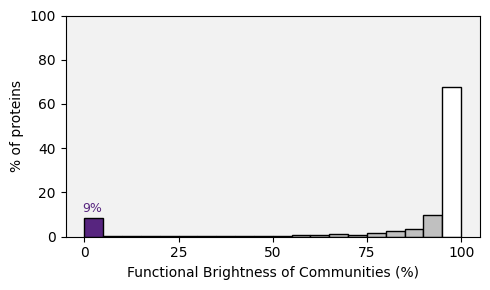

In [19]:
# make a histogram showing the percentage of dark communities to which queryIDs have been linked

fig, ax = plt.subplots(figsize=(5, 3))

tmp = atlas_search_results_maped_merged

# Compute histogram
h, _ = np.histogram(tmp.brightness.astype(float), bins=[i for i in range(0, 105, 5)])
n_dark = h[0]
h = h * 100 / sum(h)

# Colors for the bars
colors = ['#57257F'] + ['silver'] * (len(h) - 2) + ['white']

# X and Y values
x = (range(len(h)))
y = (h)

# Plotting the histogram
ax.bar(x, y, 1, align='edge', color=colors, edgecolor='k')
ax.set_facecolor('#F2F2F2')
ax.set_xticks(range(0, 21, 5))
ax.set_xticklabels(range(0, 101, 25))
ax.set_ylabel('% of proteins')
ax.set_xlabel('Functional Brightness of Communities (%)')

ax.set_ylim(0, 100)

percentage_dark = round(h[0])
ax.text(-0.1, percentage_dark + 1, '{}%'.format(percentage_dark),
        verticalalignment='bottom', horizontalalignment='left',
        color='#57257F', fontsize=9)

print('All', 'n =', len(tmp), 'n_dark =', n_dark, '%dark =', percentage_dark)

# Adjust layout and save the figure
plt.tight_layout()

plt.savefig('dark_communities.png', dpi=2000)
plt.show()

All n = 2870087 n_dark = 120985 %dark = 4


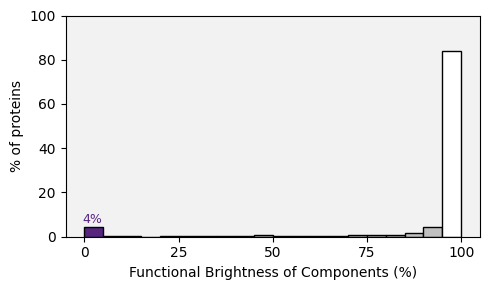

In [20]:
# make a histogram showing the percentage of dark components to which queryIDs have been linked

fig, ax = plt.subplots(figsize=(5, 3))

tmp = atlas_search_results_maped_with_componentID

# Compute histogram
h, _ = np.histogram(tmp.component_brightness.astype(float), bins=[i for i in range(0, 105, 5)])
n_dark = h[0]
h = h * 100 / sum(h)

# Colors for the bars
colors = ['#57257F'] + ['silver'] * (len(h) - 2) + ['white']

# X and Y values
x = (range(len(h)))
y = (h)

# Plotting the histogram
ax.bar(x, y, 1, align='edge', color=colors, edgecolor='k')
ax.set_facecolor('#F2F2F2')
ax.set_xticks(range(0, 21, 5))
ax.set_xticklabels(range(0, 101, 25))
ax.set_ylabel('% of proteins')
ax.set_xlabel('Functional Brightness of Components (%)')


ax.set_ylim(0, 100)

percentage_dark = round(h[0])
ax.text(-0.1, percentage_dark + 1, '{}%'.format(percentage_dark),
        verticalalignment='bottom', horizontalalignment='left',
        color='#57257F', fontsize=9)

print('All', 'n =', len(tmp), 'n_dark =', n_dark, '%dark =', percentage_dark)

# Adjust layout and save the figure
plt.tight_layout()

plt.savefig('components_darkness.png', dpi=2000)
plt.show()

In [21]:
# II PART of analysis: calculate taxonomic diversity within the mapped components
# We analyzed taxonomic diversity at the genus level

In [22]:
# first delete all rows in the atlas data in which species and genus are equal to NaN 

atlas_data = atlas_data.loc[atlas_data['species'].notna()]
atlas_data = atlas_data.loc[atlas_data['genus'].notna()]
atlas_data

,uniprotIDs,superkingdom,phylum,class,order,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
0,E2MW64,Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Corynebacterium,Corynebacterium amycolatum,E2MW64,1920284[0],96.68,cc,1920284
1,D4XKM5,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter haemolyticus,N9TGA3,21487[0],99.09,cc,21487
2,N9TGA3,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter genomosp. 16BJ,N9TGA3,21487[0],99.09,cc,21487
3,A0A072CTB8,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. ETR1,N8WWZ2,51933[0],86.73,cc,51933
4,A0A077KXT1,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter guillouiae,N8WWZ2,51933[0],86.73,cc,51933
...,...,...,...,...,...,...,...,...,...,...,...,...
4727593,A0A7S2D1G0,Eukaryota,Haptophyta,NaN,Prymnesiales,Haptolina,Haptolina brevifila,A0A7S2D1G0,1612739[0],66.96,dust,1612739
4727594,A0A7S7T862,Bacteria,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Bradyrhizobium,Bradyrhizobium sp. CCBAU 51765,A0A7S7T862,1627339[0],86.50,dust,1627339
4727595,A0A7M5UYP5,Eukaryota,Cnidaria,Hydrozoa,Leptothecata,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.96,dust,1597478
4727596,A0A7M5WQ56,Eukaryota,Cnidaria,Hydrozoa,Leptothecata,Clytia,Clytia hemisphaerica,A0A7M5WQ56,1597478[0],98.96,dust,1597478


In [23]:
#select the atlas_data for mapped components in the atlas_search_results_maped_with_componentID data  

atlas_data_selected = atlas_data.loc[atlas_data['componentIDs'].isin(atlas_search_results_maped_with_componentID['componentID'])]
atlas_data_selected

,uniprotIDs,superkingdom,phylum,class,order,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs
25,A0A009ZH99,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. 479375,N9C6R8,0[83618],98.43,cc,0
26,A0A3A8EWK5,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter guerrae,N9C6R8,0[83618],98.43,cc,0
27,A0A3D2SLU6,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.43,cc,0
28,A0A3F3L832,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.43,cc,0
29,A0A427PQY7,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. FDAARGOS_515,N9C6R8,0[83618],98.43,cc,0
...,...,...,...,...,...,...,...,...,...,...,...,...
33773031,P00984,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis polylepis,P00982,0[8164],98.33,cc,0
33773032,P0DMJ6,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0
33773033,Q7LZE3,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0
33773034,Q7LZS8,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0


In [24]:
# AMR genera list = ['Acinetobacter', 'Enterococcus', 'Escherichia', 'Klebsiella', 'Pseudomonas', 'Staphylococcus', 'Enterobacter']

In [25]:
# change the name of the genus in the AMR genera list to 'AMR genus' and create a new column in which all proteins in the AMR genera list are labeled as 'AMR genus'

genus_modifed = atlas_data_selected['genus'].replace(['Acinetobacter', 'Enterococcus', 'Escherichia', 'Klebsiella', 'Pseudomonas', 'Staphylococcus', 'Enterobacter'], 'AMR genus') 
atlas_data_selected['genus_modifed'] = genus_modifed
atlas_data_selected

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_89879/298474034.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_data_selected['genus_modifed'] = genus_modifed


,uniprotIDs,superkingdom,phylum,class,order,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs,genus_modifed
25,A0A009ZH99,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. 479375,N9C6R8,0[83618],98.43,cc,0,AMR genus
26,A0A3A8EWK5,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter guerrae,N9C6R8,0[83618],98.43,cc,0,AMR genus
27,A0A3D2SLU6,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.43,cc,0,AMR genus
28,A0A3F3L832,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.43,cc,0,AMR genus
29,A0A427PQY7,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. FDAARGOS_515,N9C6R8,0[83618],98.43,cc,0,AMR genus
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33773031,P00984,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis polylepis,P00982,0[8164],98.33,cc,0,Dendroaspis
33773032,P0DMJ6,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0,Dendroaspis
33773033,Q7LZE3,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0,Dendroaspis
33773034,Q7LZS8,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0,Dendroaspis


In [26]:
# select only those proteins in atlas_data_selected that belong to components containing at least one protein labeled as AMR genus 

AMR_containing_components = atlas_data_selected['componentIDs'].loc[atlas_data_selected['genus_modifed'] == 'AMR genus']
atlas_data_for_diversity_evaluation = atlas_data_selected.loc[atlas_data_selected['componentIDs'].isin(AMR_containing_components)]
atlas_data_for_diversity_evaluation

,uniprotIDs,superkingdom,phylum,class,order,genus,species,UniRef50IDs,communityIDs,brightness,label,componentIDs,genus_modifed
25,A0A009ZH99,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. 479375,N9C6R8,0[83618],98.43,cc,0,AMR genus
26,A0A3A8EWK5,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter guerrae,N9C6R8,0[83618],98.43,cc,0,AMR genus
27,A0A3D2SLU6,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.43,cc,0,AMR genus
28,A0A3F3L832,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter ursingii,N9C6R8,0[83618],98.43,cc,0,AMR genus
29,A0A427PQY7,Bacteria,Pseudomonadota,Gammaproteobacteria,Moraxellales,Acinetobacter,Acinetobacter sp. FDAARGOS_515,N9C6R8,0[83618],98.43,cc,0,AMR genus
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33773031,P00984,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis polylepis,P00982,0[8164],98.33,cc,0,Dendroaspis
33773032,P0DMJ6,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0,Dendroaspis
33773033,Q7LZE3,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0,Dendroaspis
33773034,Q7LZS8,Eukaryota,Chordata,Lepidosauria,Squamata,Dendroaspis,Dendroaspis angusticeps,P00982,0[8164],98.33,cc,0,Dendroaspis


In [27]:
# define a function to calculate the taxonomic diversity in each component 
# we used evenness that is Shannon index normalized by the number of taxonomic units in each analyzed group (in our case by the number of unique genera in each component) 
# about Shannon index here: https://www.omnicalculator.com/ecology/shannon-index

import math
from collections import Counter

def evenness(grouped_series):
    # Calculate the frequency of each unique value in the series
    freq = Counter(grouped_series)
    
    # Total number of elements in the series
    total_count = len(grouped_series)
    
    # Calculate the probability of each value occurring
    probabilities = {value: count / total_count for value, count in freq.items()}
    
    # Calculate the Shannon entropy
    entropy = -sum(prob * math.log2(prob) for prob in probabilities.values())
    
    # Number of unique species
    num_species = len(freq)

    if num_species == 1:
        return 0
    
    # Calculate the evenness
    evenness = entropy / math.log2(num_species)
    
    return evenness

In [28]:
# calculate ESKAPE_relative_evenness for each component where all proteins from AMR genera list are labeled as 'AMR genus'
# here we look at how diverse the proteins are at the genus level in each component relative to the proteins in the list of AMR genera that are labeled as "AMR genus"

atlas_data_for_diversity_evaluation_grouped = atlas_data_for_diversity_evaluation.groupby(['componentIDs'])
ESKAPE_relative_evenness = atlas_data_for_diversity_evaluation_grouped['genus_modifed'].apply(evenness)
ESKAPE_relative_evenness_list = list(ESKAPE_relative_evenness)

#cloumn of indexes for diversity index
componentIDs = ESKAPE_relative_evenness.index.tolist()

In [29]:
# calculate ESKAPE genus evenness for each component. Here we analyzed taxanomic diversity only within proteins from AMR genera list. 

atlas_data_selected_AMR = atlas_data_for_diversity_evaluation.loc[atlas_data_for_diversity_evaluation['genus_modifed'] == 'AMR genus'] # select only those proteins that are from AMR genera list 
atlas_data_selected_AMR_grouped = atlas_data_selected_AMR.groupby(['componentIDs'])
ESKAPE_genus_evenness_index = atlas_data_selected_AMR_grouped['genus'].apply(evenness)
ESKAPE_genus_evenness_index_list = list(ESKAPE_genus_evenness_index) 

In [30]:
# calculate a portion of proteins from AMR genera list in each component

ESKAPE_proportion = atlas_data_for_diversity_evaluation_grouped['genus_modifed'].apply(lambda x: x.str.contains('AMR genus').sum() / len(x)).tolist()

In [31]:
len(ESKAPE_proportion)

2544

In [32]:
# combine ESKAPE_relative_evenness_index, ESKAPE_genus_evenness_index and ESKAPE_proportion into one data frame

diversity_metrics_of_selected_components = pd.DataFrame({'componentIDs': componentIDs, 'ESKAPE_relative_evenness': ESKAPE_relative_evenness_list, 'ESKAPE_genus_evenness': ESKAPE_genus_evenness_index_list, 'ESKAPE_proportion': ESKAPE_proportion})
diversity_metrics_of_selected_components

,componentIDs,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
0,0,0.632360,0.810699,0.069490
1,2,0.759871,0.694650,0.100531
2,3,0.695780,0.511121,0.167420
3,4,0.867790,0.289006,0.045716
4,5,0.782039,0.560337,0.034179
...,...,...,...,...
2539,240403,0.000000,0.000000,1.000000
2540,240467,0.828871,0.000000,0.222222
2541,240823,1.000000,0.000000,0.333333
2542,240867,0.929966,0.918296,0.200000


In [33]:
# add calculated diversity metrics to  the atlas_search_results_maped_with_componentIDs
# in the atlas_search_results_maped_with_componentID there are components that do not have proteins from the list of AMR genera
# first leave only those components that have at least one pretein from the list of AMR genera
# and then add component(!) metrics

atlas_search_results_maped_with_componentID_selected = atlas_search_results_maped_with_componentID.loc[atlas_search_results_maped_with_componentID['componentID'].isin(atlas_data_for_diversity_evaluation['componentIDs'])]
atlas_search_results_maped_with_componentID_selected.sort_values(by='componentID', inplace=True)


ESKAPE_relative_evenness_list = []
ESKAPE_genus_evenness_list = []
ESKAPE_proportion_list = []
previous_componentID = None

for componentID in tqdm.tqdm(atlas_search_results_maped_with_componentID_selected['componentID'], total=len(atlas_search_results_maped_with_componentID_selected), desc=' ... Collecting componentID counts', bar_format="{l_bar}{bar}{r_bar} [ time left: {remaining}, time spent: {elapsed}]", position=0, leave=True):
        
    if componentID != previous_componentID:
        
        cur_ESKAPE_relative_evenness = diversity_metrics_of_selected_components['ESKAPE_relative_evenness'].loc[diversity_metrics_of_selected_components['componentIDs'] == componentID].values[0]
        cur_ESKAPE_genus_evenness = diversity_metrics_of_selected_components['ESKAPE_genus_evenness'].loc[diversity_metrics_of_selected_components['componentIDs'] == componentID].values[0]
        cur_ESKAPE_proportion = diversity_metrics_of_selected_components['ESKAPE_proportion'].loc[diversity_metrics_of_selected_components['componentIDs'] == componentID].values[0]
        
        previous_componentID = componentID
    
    ESKAPE_relative_evenness_list.append(cur_ESKAPE_relative_evenness)
    ESKAPE_genus_evenness_list.append(cur_ESKAPE_genus_evenness)
    ESKAPE_proportion_list.append(cur_ESKAPE_proportion)


atlas_search_results_maped_with_componentID_selected['ESKAPE_relative_evenness'] = ESKAPE_relative_evenness_list
atlas_search_results_maped_with_componentID_selected['ESKAPE_genus_evenness'] = ESKAPE_genus_evenness_list
atlas_search_results_maped_with_componentID_selected['ESKAPE_proportion'] = ESKAPE_proportion_list

atlas_search_results_maped_with_componentID_selected.reset_index(drop=True, inplace=True)
atlas_search_results_maped_with_componentID_selected

/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_89879/1703632588.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_with_componentID_selected.sort_values(by='componentID', inplace=True)
 ... Collecting componentID counts: 100%|██████████| 2691756/2691756 [00:01<00:00, 2129695.30it/s] [ time left: 00:00, time spent: 00:01]
/var/folders/jw/dtzx9qw5623bsv0mmsn7ds2m7jqbzn/T/ipykernel_89879/1703632588.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlas_search_results_maped_with_componentID_selected['ESKAPE_relative_evennes

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
0,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44,0.632360,0.810699,0.069490
1,N5938_RS19225,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
2,O4M85_RS17570,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
3,RW109_RS21790,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
4,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44,0.632360,0.810699,0.069490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691751,P4N66_RS27185,P07684,0.987,406,5,0,1,406,1,406,4.001000e-258,794,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691752,QAY87_RS29255,Q5BLX3,0.996,313,1,0,15,327,1,313,3.136000e-200,627,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691753,Q7F19_RS33075,Q5BLX3,0.996,313,1,0,15,327,1,313,3.136000e-200,627,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691754,JMX72_RS24810,P07684,0.987,406,5,0,1,406,1,406,4.001000e-258,794,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667


In [34]:
# save the final table with results 

atlas_search_results_maped_with_componentID_selected.to_csv('./eclipse.csv')

# Description of the final table

**queryID**: protein seq from the fasta files of S. aureus proteins 

**targetID**: UniRef50 representative to which the queryID was aligned with the best score

**fident**: Fraction of identical matches

**alnlen**: Alignment length (number of aligned columns)

**mismatch**: Number of mismatches

**gapopen**: Number of gap open events (note: this is NOT the number of gap characters)

**qstart**: 1-indexed alignment start position in query sequence

**qend**: 1-indexed alignment end position in query sequence

**tstart**: 1-indexed alignment start position in target sequence

**tend**: 1-indexed alignment end position in target sequence

**eVal**: E-value

**bits**: Bit score

**communityID**: communityID from the atlas to which the UniRef50 representative belongs

**brightness**: brightness of a community

**componentID**: componentID from the atlas to which the UniRef50 representative belongs

**component_brightness**: median brightness of a component

**ESKAPE_relative_evenness**: Normalized Shannon index reflecting taxanomic diversity of a component at the genus level in the condition where all proteins from the AMR genera list are labeled as “genus AMR”. If ESKAPE_relative_evenness is 0.0, it means that either all proteins in the component are from the same genus or only from the AMR genera list. If ESKAPE_relative_evenness increases, it means that taxonomic diversity also increases, and the component contains proteins not only from the list of AMR genera

**ESKAPE_genus_evenness**: Normalized Shannon index reflecting taxonomic diversity only within proteins from the list of AMR genera. If ESKAPE_genus_evenness is 0.0, it means that proteins in the component belong to only one AMR genus.If ESKAPE_genus_evenness is greater than 0.0, it means that proteins from several AMR genera are present in the component. 

**ESKAPE_proportion**: a portion of proteins from the AMR genera list in the component 

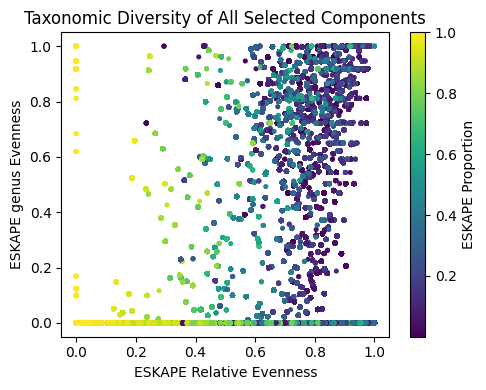

In [35]:
#make a scetter plot of taxonomic diversity for the all selected components

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

scatter = ax.scatter(
    atlas_search_results_maped_with_componentID_selected['ESKAPE_relative_evenness'], 
    atlas_search_results_maped_with_componentID_selected['ESKAPE_genus_evenness'], 
    c=atlas_search_results_maped_with_componentID_selected['ESKAPE_proportion'], 
    cmap='viridis', 
    marker='o', 
    s=7)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('ESKAPE Proportion', fontsize=10) 

ax.set_title('Taxonomic Diversity of All Selected Components', fontsize=12) 
ax.set_xlabel('ESKAPE Relative Evenness', fontsize=10)    
ax.set_ylabel('ESKAPE genus Evenness', fontsize=10) 
ax.patch.set_alpha(0)

fig.tight_layout()

# Save the plot with a transparent background
fig.savefig('taxonomic_diversity_of_All_components.png', dpi=2000, transparent=True)

# Show the plot
plt.show()

In [36]:
# select queryIDs that were maped to dark components (median darkness <= 4%)
atlas_search_results_maped_with_componentID_selected_dark = atlas_search_results_maped_with_componentID_selected.loc[atlas_search_results_maped_with_componentID_selected['component_brightness'] <= 5]
atlas_search_results_maped_with_componentID_selected_dark

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
2006446,PALA23_RS25565,A0A367M2P5,0.954,110,5,0,55,164,3,112,3.428000e-65,224,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
2006447,M2I93_RS28125,A0A367M2P5,0.963,110,4,0,55,164,3,112,7.077000e-66,226,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
2006448,MKF35_RS10835,A0A367M2P5,0.963,110,4,0,55,164,3,112,7.077000e-66,226,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
2006449,PALA4_RS27830,A0A367M2P5,0.945,110,6,0,55,164,3,112,4.699000e-65,223,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
2006450,PALA36_RS28265,A0A367M2P5,0.945,110,6,0,55,164,3,112,4.699000e-65,223,133[1],0.0,133,0.0,0.795258,0.131107,0.058511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691745,HV91_RS26755,Q5W380,0.822,124,22,0,1,124,1,124,2.897000e-56,210,240823[0],0.0,240823,0.0,1.000000,0.000000,0.333333
2691746,HUK75_RS26255,Q5W380,0.822,124,22,0,1,124,1,124,7.444000e-61,220,240823[0],0.0,240823,0.0,1.000000,0.000000,0.333333
2691747,CDL16_RS17765,Q5W380,0.824,125,22,0,1,125,1,125,6.633000e-68,229,240823[0],0.0,240823,0.0,1.000000,0.000000,0.333333
2691748,PA34_RS27525,Q5W380,0.822,124,22,0,1,124,1,124,7.444000e-61,220,240823[0],0.0,240823,0.0,1.000000,0.000000,0.333333


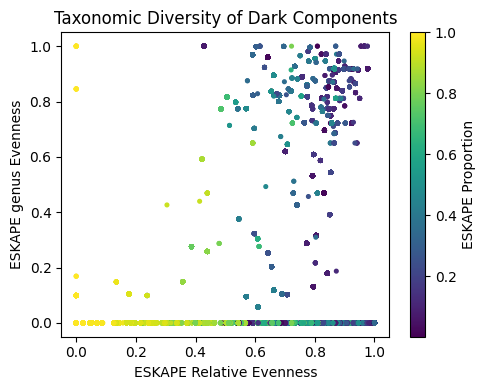

In [37]:
#make a scetter plot of taxonomic diversity only for dark maped components 

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

scatter = ax.scatter(
    atlas_search_results_maped_with_componentID_selected_dark['ESKAPE_relative_evenness'], 
    atlas_search_results_maped_with_componentID_selected_dark['ESKAPE_genus_evenness'], 
    c=atlas_search_results_maped_with_componentID_selected_dark['ESKAPE_proportion'], 
    cmap='viridis', 
    marker='o', 
    s=7)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('ESKAPE Proportion', fontsize=10) 

ax.set_title('Taxonomic Diversity of Dark Components', fontsize=12) 
ax.set_xlabel('ESKAPE Relative Evenness', fontsize=10)      
ax.set_ylabel('ESKAPE genus Evenness', fontsize=10)
ax.patch.set_alpha(0)

fig.tight_layout()

fig.savefig('taxonomic_diversity_of_dark_components.png', dpi=2000, transparent=True)

plt.show()

In [38]:
# add sequences to each queryID in the atlas_search_results data frame


atlas_search_results = pd.read_csv('./ECLIPSE.csv', index_col='Unnamed: 0')
atlas_search_results

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
0,GO602_RS04115,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44,0.632360,0.810699,0.069490
1,N5938_RS19225,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
2,O4M85_RS17570,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
3,RW109_RS21790,A0A072ZHN0,1.000,193,0,0,1,193,1,193,3.323000e-124,395,0[100010],98.44,0,97.44,0.632360,0.810699,0.069490
4,MMZ72_RS22095,A0A2S6UG48,0.515,258,125,0,3,260,23,280,4.162000e-80,273,0[10000],99.32,0,97.44,0.632360,0.810699,0.069490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691751,P4N66_RS27185,P07684,0.987,406,5,0,1,406,1,406,4.001000e-258,794,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691752,QAY87_RS29255,Q5BLX3,0.996,313,1,0,15,327,1,313,3.136000e-200,627,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691753,Q7F19_RS33075,Q5BLX3,0.996,313,1,0,15,327,1,313,3.136000e-200,627,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667
2691754,JMX72_RS24810,P07684,0.987,406,5,0,1,406,1,406,4.001000e-258,794,240924[0],94.89,240924,97.32,0.702195,0.905495,0.416667


In [39]:
# Read all FASTA files and build:
#   (1) seq_df          -- queryID + SEQ table used downstream
#   (2) queryID_to_strain.csv -- universal protein->strain mapping for Part III S4 scoring
#
# Strain identity is extracted from the .faa FILENAME, not from the sequence ID.
# This is necessary because NCBI queryIDs (e.g. ABD20461.1) are protein accessions
# that contain no strain information. The filename is the only reliable source.
#
# Extraction priority (works for any ESKAPE pathogen):
#   1. GCF/GCA accession in filename  ->  GCF_000013425.1_ASM1342v1_protein.faa  ->  GCF_000013425.1
#   2. Full filename stem (no ext)    ->  PAO1.faa  ->  PAO1 / Ab307-0294.faa  ->  Ab307-0294

from Bio import SeqIO
import os, re

directory_path = './faa'

_accession_re = re.compile(r'(GC[FA]_\d+\.\d+)', re.IGNORECASE)

def strain_from_filename(fname):
    """Return a stable, unique strain ID from any NCBI or custom .faa filename."""
    m = _accession_re.search(fname)
    if m:
        return m.group(1)                      # e.g. GCF_000013425.1
    stem = fname
    for ext in ('.faa', '.fasta', '.fa', '.fna'):
        if stem.lower().endswith(ext):
            stem = stem[:-len(ext)]
            break
    return stem                                # e.g. PAO1, Ab307-0294, MRSA252

queryID      = []
seq          = []
strain_label = []   # one entry per protein -- carries strain identity through the pipeline

for fasta_file in os.listdir(directory_path):

    if fasta_file.startswith('.'):            # skip hidden files (.DS_Store etc.)
        continue
    fasta_file_path = os.path.join(directory_path, fasta_file)
    if not os.path.isfile(fasta_file_path):   # skip subdirectories
        continue

    strain = strain_from_filename(fasta_file)

    try:
        sequences = list(SeqIO.parse(fasta_file_path, "fasta"))
    except UnicodeDecodeError:
        with open(fasta_file_path, encoding="latin-1") as handle:
            sequences = list(SeqIO.parse(handle, "fasta"))

    for seq_record in sequences:
        queryID.append(seq_record.id)
        seq.append(str(seq_record.seq))
        strain_label.append(strain)

seq_df = pd.DataFrame({'queryID': queryID, 'SEQ': seq, 'strain': strain_label})

# Save the protein -> strain mapping for Part III (S4 strain coverage scoring)
strain_map = seq_df[['queryID', 'strain']].drop_duplicates()
strain_map.to_csv('./queryID_to_strain.csv', index=False)

print(f"Total proteins read : {len(seq_df):,}")
print(f"Unique strains found: {seq_df['strain'].nunique():,}")
print(f"Strain mapping saved: queryID_to_strain.csv")
print()
print("Sample (first 5 rows):")
print(seq_df[['queryID', 'strain']].head())
seq_df

Total proteins read : 3,908,421
Unique strains found: 635
Strain mapping saved: queryID_to_strain.csv

Sample (first 5 rows):
        queryID                           strain
0  Y880_RS00010  Pseudomonas_aeruginosa_PAK_6441
1  Y880_RS00015  Pseudomonas_aeruginosa_PAK_6441
2  Y880_RS00020  Pseudomonas_aeruginosa_PAK_6441
3  Y880_RS00025  Pseudomonas_aeruginosa_PAK_6441
4  Y880_RS00030  Pseudomonas_aeruginosa_PAK_6441


,queryID,SEQ,strain
0,Y880_RS00010,MAAWLVRMSAYAELHCLSNFSFQRGASSAAELFARAARLGYRALAI...,Pseudomonas_aeruginosa_PAK_6441
1,Y880_RS00015,MLWACILLPQLAMDSALRQRNNPDAPLALLGGPAQRRQLQAVNPAA...,Pseudomonas_aeruginosa_PAK_6441
2,Y880_RS00020,MWKGQSAVPAGASLPTGHARLDALLPGGGWPEHALNEILHARDGVG...,Pseudomonas_aeruginosa_PAK_6441
3,Y880_RS00025,MDTLAPESTRQNLRSQRLNLLTNEPHQRLESLVKSKEPFASRDNFA...,Pseudomonas_aeruginosa_PAK_6441
4,Y880_RS00030,MHRSSQVLPALILGLAMNATLADEPTPPANCINTEVNGYQALSYEC...,Pseudomonas_aeruginosa_PAK_6441
...,...,...,...
3908416,PAC13_RS35225,MAARITDDEWDELTPENFDTTALLRAVDAVDVLRGDLNDSADGAPP...,Pseudomonas_aeruginosa_C13_22800
3908417,PAC13_RS35230,MQKRIIEGVEVQRSSGNVFADLGLPDAEKLKIKTGLVVEIRRAMRA...,Pseudomonas_aeruginosa_C13_22800
3908418,PAC13_RS35235,MTNKEKPLEWIASSHKDLMALPSDVRRRFGYALSLAQIGDQDDAAK...,Pseudomonas_aeruginosa_C13_22800
3908419,PAC13_RS35240,MLVGYMRVSSDSDRQSTDLQRDALLAAGVDPRHLFEDRASGAKDDR...,Pseudomonas_aeruginosa_C13_22800


In [40]:
# Select only queryIDs that are in atlas_search_results, drop duplicates,
# sort by queryID. The strain column is preserved through this filter.

seq_df = seq_df.loc[seq_df['queryID'].isin(atlas_search_results['queryID'])]
seq_df = seq_df.drop_duplicates(subset='queryID')   # explicit subset preserves strain
seq_df.sort_values(by=['queryID'], inplace=True)

# Re-save queryID_to_strain.csv AFTER filtering to only matched queryIDs.
# This ensures the mapping contains exactly the proteins that will be analysed,
# avoiding unmapped-protein warnings in Part III.
strain_map_filtered = seq_df[['queryID', 'strain']].drop_duplicates()
strain_map_filtered.to_csv('./queryID_to_strain.csv', index=False)
print(f"queryID_to_strain.csv updated after atlas filter:")
print(f"  Proteins matched to atlas : {len(strain_map_filtered):,}")
print(f"  Unique strains retained   : {strain_map_filtered['strain'].nunique():,}")

seq_df

queryID_to_strain.csv updated after atlas filter:
  Proteins matched to atlas : 2,691,756
  Unique strains retained   : 635


,queryID,SEQ,strain
1330657,A0K_RS00005,MSVELWQQCVDLLRDELPSQQFNTWIRPLQVEAEGDELRVYAPNRF...,Pseudomonas_aeruginosa_PACS2_84
1326196,A0K_RS00015,MSLTRVSVTAVRNLHPVTLSPSPRINILYGDNGSGKTSVLEAIHLL...,Pseudomonas_aeruginosa_PACS2_84
1326197,A0K_RS00020,MSENNTYDSSSIKVLKGLDAVRKRPGMYIGDTDDGTGLHHMVFEVV...,Pseudomonas_aeruginosa_PACS2_84
1331773,A0K_RS00030,MSRSLLILDRDGVINLDSDDYIKTLDEWIPIPSSIEAIARLSQAGW...,Pseudomonas_aeruginosa_PACS2_84
1330658,A0K_RS00035,MKRLKKTLHLSSLSLASLALSSAALAAAPVMLDQGKEWTESHRQDF...,Pseudomonas_aeruginosa_PACS2_84
...,...,...,...
2873720,Ysp71_RS33380,MSAVTQHHADELARGADELGVALDADKQRQLLAYLALLIKWNKAYN...,Pseudomonas_aeruginosa_Y71_9532
2873721,Ysp71_RS33385,MDFPTRFDVIVIGGGHAGTEAALAAARMGVKTLLLTHNVETLGQMS...,Pseudomonas_aeruginosa_Y71_9532
2873724,Ysp71_RS33405,MQAATETIVAIATAQGRGGVGIVRISGPLAGQIAVAVSGRQLKARH...,Pseudomonas_aeruginosa_Y71_9532
2873725,Ysp71_RS33410,MDIQRSILIVALAVVSYLLVLQWNKDYGQPELPAASASMNTTQGLP...,Pseudomonas_aeruginosa_Y71_9532


In [41]:
# sort values in the atlas_seqrch_result by queryID

atlas_search_results.sort_values(by=['queryID'], inplace=True)
atlas_search_results

,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
1640068,A0K_RS00005,A0A0A2W3F8,0.647,471,147,0,25,495,2,418,3.675000e-175,560,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
1656506,A0K_RS00015,A0A451EP17,0.605,360,142,0,1,360,1,360,9.077000e-146,467,0[70148],99.73,0,97.44,0.632360,0.810699,0.069490
1640100,A0K_RS00020,A0A0A2W3F8,0.675,799,259,0,8,806,1092,1890,0.000000e+00,1116,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
590232,A0K_RS00030,A0A4Q6F4N6,0.773,137,31,0,41,177,1,137,2.012000e-66,228,0[19063],99.28,0,97.44,0.632360,0.810699,0.069490
2080939,A0K_RS00035,A0A1W9GXS9,0.568,410,175,0,162,568,2,411,4.842000e-138,455,516[15],60.10,516,69.58,0.859917,0.000000,0.012848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406917,Ysp71_RS33380,A0A2G2Q084,0.533,210,98,0,1,210,1,210,3.068000e-67,232,0[49693],98.63,0,97.44,0.632360,0.810699,0.069490
1626271,Ysp71_RS33385,Q6F9Q1,0.720,626,175,0,1,626,1,625,1.207000e-296,918,0[6765],99.85,0,97.44,0.632360,0.810699,0.069490
1975689,Ysp71_RS33405,A0A7C5CPU8,0.652,190,66,0,1,190,1,190,4.982000e-65,237,39[8],98.03,39,98.82,0.782502,0.626428,0.013778
1975790,Ysp71_RS33410,A0A3M4K3S9,0.757,409,94,0,170,578,1,388,2.099000e-201,640,39[17],98.97,39,98.82,0.782502,0.626428,0.013778


In [42]:
# Remove any queryIDs labeled 'LongLink' -- this can occur when MMseqs2 truncates
# a sequence name that exceeds its internal identifier length limit.
# Using a label-based filter instead of a hardcoded index makes this universal.

longlink_mask = atlas_search_results['queryID'] == 'LongLink'
n_longlink = longlink_mask.sum()
if n_longlink > 0:
    print(f"Dropping {n_longlink} row(s) where queryID == 'LongLink'")
    atlas_search_results = atlas_search_results.loc[~longlink_mask].reset_index(drop=True)
else:
    print("No LongLink entries found -- nothing dropped.")
atlas_search_results

No LongLink entries found -- nothing dropped.


,queryID,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
1640068,A0K_RS00005,A0A0A2W3F8,0.647,471,147,0,25,495,2,418,3.675000e-175,560,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
1656506,A0K_RS00015,A0A451EP17,0.605,360,142,0,1,360,1,360,9.077000e-146,467,0[70148],99.73,0,97.44,0.632360,0.810699,0.069490
1640100,A0K_RS00020,A0A0A2W3F8,0.675,799,259,0,8,806,1092,1890,0.000000e+00,1116,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
590232,A0K_RS00030,A0A4Q6F4N6,0.773,137,31,0,41,177,1,137,2.012000e-66,228,0[19063],99.28,0,97.44,0.632360,0.810699,0.069490
2080939,A0K_RS00035,A0A1W9GXS9,0.568,410,175,0,162,568,2,411,4.842000e-138,455,516[15],60.10,516,69.58,0.859917,0.000000,0.012848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406917,Ysp71_RS33380,A0A2G2Q084,0.533,210,98,0,1,210,1,210,3.068000e-67,232,0[49693],98.63,0,97.44,0.632360,0.810699,0.069490
1626271,Ysp71_RS33385,Q6F9Q1,0.720,626,175,0,1,626,1,625,1.207000e-296,918,0[6765],99.85,0,97.44,0.632360,0.810699,0.069490
1975689,Ysp71_RS33405,A0A7C5CPU8,0.652,190,66,0,1,190,1,190,4.982000e-65,237,39[8],98.03,39,98.82,0.782502,0.626428,0.013778
1975790,Ysp71_RS33410,A0A3M4K3S9,0.757,409,94,0,170,578,1,388,2.099000e-201,640,39[17],98.97,39,98.82,0.782502,0.626428,0.013778


In [43]:
# Merge sequences (and strain label) into atlas_search_results.
# The strain column from seq_df is carried into eclipse_seq.csv automatically,
# making it available for any downstream use alongside queryID_to_strain.csv.

atlas_search_results_with_seq = pd.merge(seq_df, atlas_search_results, on='queryID')
atlas_search_results_with_seq.to_csv('./eclipse_seq.csv')  # strain column included

# Confirm strain column is present
if 'strain' in atlas_search_results_with_seq.columns:
    print(f"strain column present in eclipse_seq.csv -")
    print(f"  Unique strains: {atlas_search_results_with_seq['strain'].nunique():,}")
else:
    print("WARNING: strain column missing from eclipse_seq.csv -- check seq_df")

atlas_search_results_with_seq

strain column present in eclipse_seq.csv -
  Unique strains: 635


,queryID,SEQ,strain,targetID,fident,alnlen,mismatch,gapopen,qstart,qend,...,tend,eVal,bits,communityID,brightness,componentID,component_brightness,ESKAPE_relative_evenness,ESKAPE_genus_evenness,ESKAPE_proportion
0,A0K_RS00005,MSVELWQQCVDLLRDELPSQQFNTWIRPLQVEAEGDELRVYAPNRF...,Pseudomonas_aeruginosa_PACS2_84,A0A0A2W3F8,0.647,471,147,0,25,495,...,418,3.675000e-175,560,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
1,A0K_RS00015,MSLTRVSVTAVRNLHPVTLSPSPRINILYGDNGSGKTSVLEAIHLL...,Pseudomonas_aeruginosa_PACS2_84,A0A451EP17,0.605,360,142,0,1,360,...,360,9.077000e-146,467,0[70148],99.73,0,97.44,0.632360,0.810699,0.069490
2,A0K_RS00020,MSENNTYDSSSIKVLKGLDAVRKRPGMYIGDTDDGTGLHHMVFEVV...,Pseudomonas_aeruginosa_PACS2_84,A0A0A2W3F8,0.675,799,259,0,8,806,...,1890,0.000000e+00,1116,0[69171],99.95,0,97.44,0.632360,0.810699,0.069490
3,A0K_RS00030,MSRSLLILDRDGVINLDSDDYIKTLDEWIPIPSSIEAIARLSQAGW...,Pseudomonas_aeruginosa_PACS2_84,A0A4Q6F4N6,0.773,137,31,0,41,177,...,137,2.012000e-66,228,0[19063],99.28,0,97.44,0.632360,0.810699,0.069490
4,A0K_RS00035,MKRLKKTLHLSSLSLASLALSSAALAAAPVMLDQGKEWTESHRQDF...,Pseudomonas_aeruginosa_PACS2_84,A0A1W9GXS9,0.568,410,175,0,162,568,...,411,4.842000e-138,455,516[15],60.10,516,69.58,0.859917,0.000000,0.012848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2691751,Ysp71_RS33380,MSAVTQHHADELARGADELGVALDADKQRQLLAYLALLIKWNKAYN...,Pseudomonas_aeruginosa_Y71_9532,A0A2G2Q084,0.533,210,98,0,1,210,...,210,3.068000e-67,232,0[49693],98.63,0,97.44,0.632360,0.810699,0.069490
2691752,Ysp71_RS33385,MDFPTRFDVIVIGGGHAGTEAALAAARMGVKTLLLTHNVETLGQMS...,Pseudomonas_aeruginosa_Y71_9532,Q6F9Q1,0.720,626,175,0,1,626,...,625,1.207000e-296,918,0[6765],99.85,0,97.44,0.632360,0.810699,0.069490
2691753,Ysp71_RS33405,MQAATETIVAIATAQGRGGVGIVRISGPLAGQIAVAVSGRQLKARH...,Pseudomonas_aeruginosa_Y71_9532,A0A7C5CPU8,0.652,190,66,0,1,190,...,190,4.982000e-65,237,39[8],98.03,39,98.82,0.782502,0.626428,0.013778
2691754,Ysp71_RS33410,MDIQRSILIVALAVVSYLLVLQWNKDYGQPELPAASASMNTTQGLP...,Pseudomonas_aeruginosa_Y71_9532,A0A3M4K3S9,0.757,409,94,0,170,578,...,388,2.099000e-201,640,39[17],98.97,39,98.82,0.782502,0.626428,0.013778
